# Importing the necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Conv2D , MaxPool2D , Flatten , Dropout , BatchNormalization
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,matthews_corrcoef,auc,roc_curve,precision_recall_curve,roc_auc_score
from keras.callbacks import ReduceLROnPlateau
import cv2
import os

In [ ]:
#model = load_model("models/model_02_03_24.h5")

# Dataset description


In [2]:
#labels = ['ABNORMAL', 'NORMAL']
img_size = 150
def get_data(data_dir, labels):
    data = [] 
    for label in labels: 
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))     # Reshaping images to preferred size
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    
    # Separate images and class numbers
    images = np.array([item[0] for item in data])
    labels = np.array([item[1] for item in data])
    
    return images, labels
    #return np.array(data)

# Loading the Dataset

In [3]:
labels = ['ABNORMAL', 'NORMAL']

train = get_data('data/data3/lung_train', labels)
test = get_data('data/data3/lung_test', labels)
val = get_data('data/data3/lung_validate', labels)

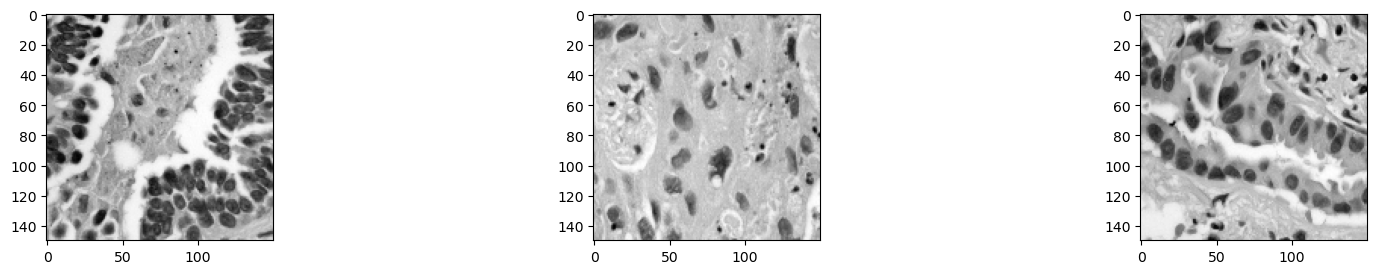

In [4]:
plt.figure(figsize=(20, 10))
plt.subplot(3, 3, 1)
plt.imshow(train[0][0], cmap='gray')
plt.subplot(3, 3, 2)
plt.imshow(test[0][0], cmap='gray')
plt.subplot(3, 3, 3)
plt.imshow(val[0][0], cmap='gray')
plt.show() 

# Data Visualization & Preprocessing

**Let's check out the dataset we're working on by picking out two data points from the dataset.**

In [5]:
abnormal = os.listdir("data/data3/lung_train/ABNORMAL")
abnormal_dir = "data/data3/lung_train/ABNORMAL"

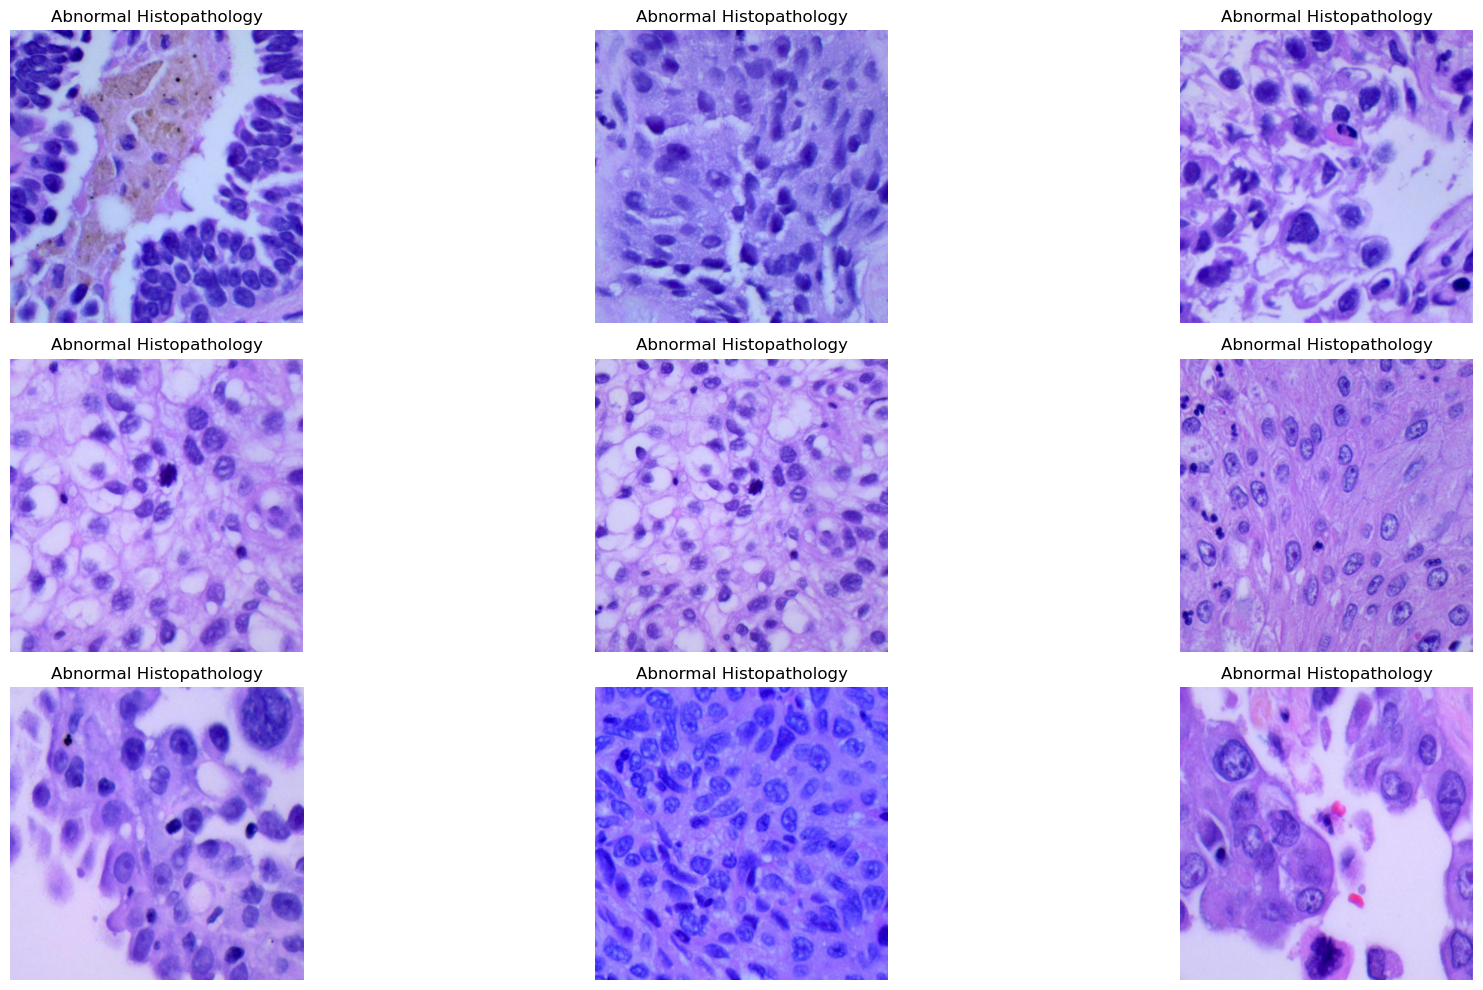

In [6]:
plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(abnormal_dir, abnormal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Abnormal Histopathology") 
plt.tight_layout()

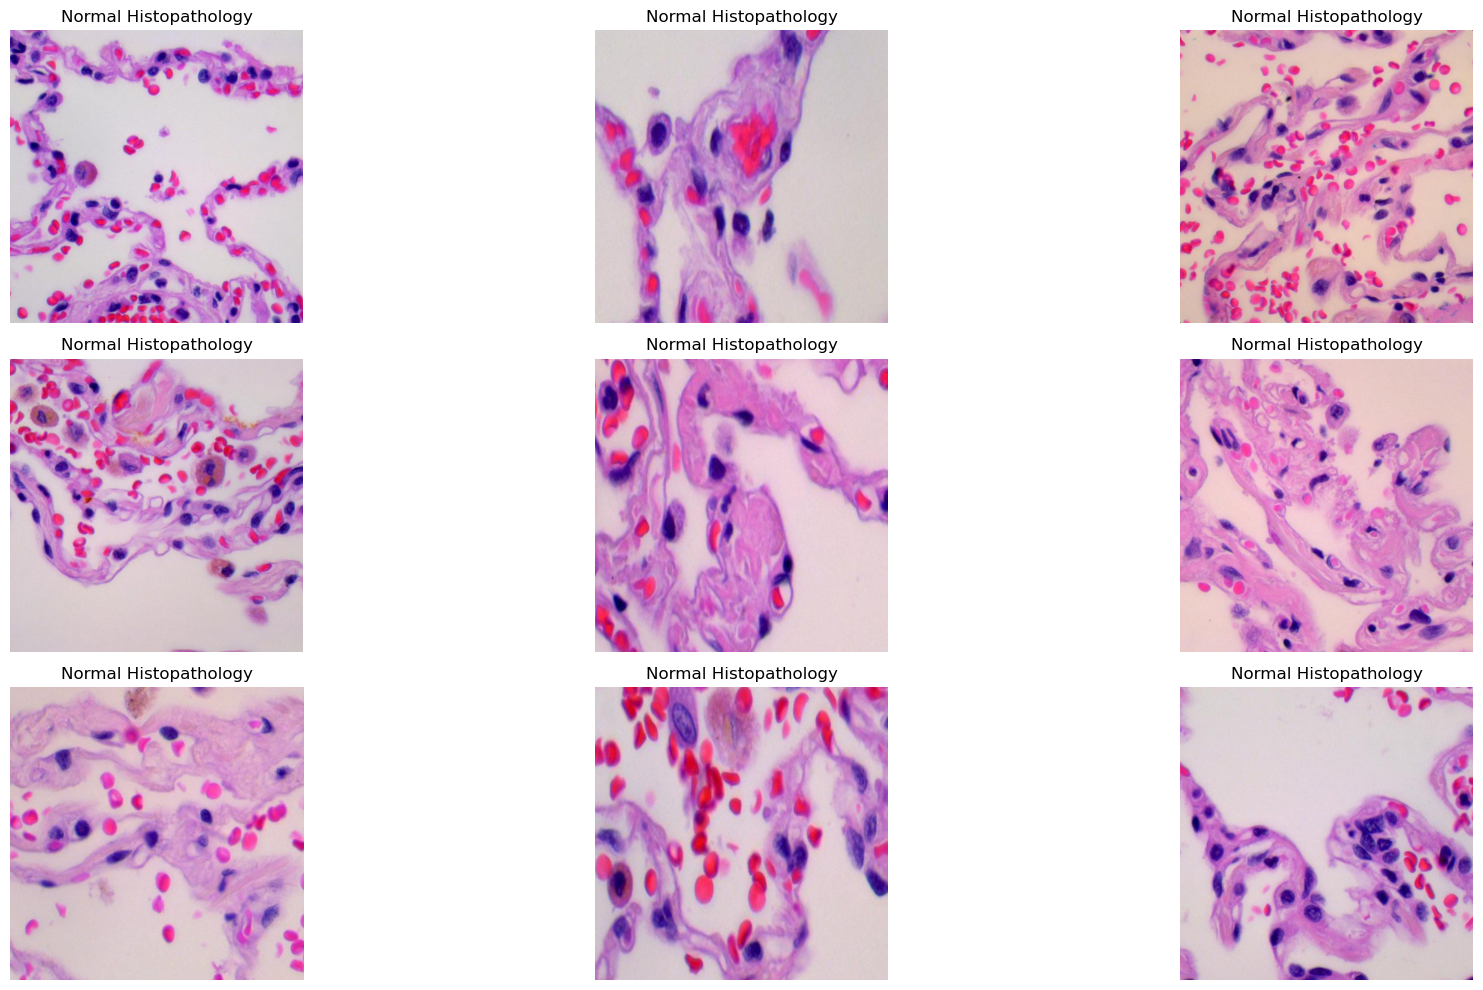

In [8]:
normal = os.listdir("data/data3/lung_train/NORMAL")
normal_dir = "data/data3/lung_train/NORMAL"

plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(normal_dir, normal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title("Normal Histopathology") 
   
plt.tight_layout()

**Let's check out the number of data points we are working with in the dataset.**

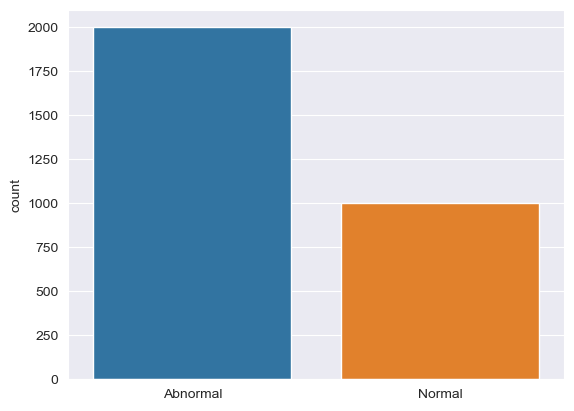

'\nlist = []\nfor i in train:\n    if(i[1] == 0):\n        list.append("Abnormal")\n    else:\n        list.append("Normal")\nsns.set_style(\'darkgrid\')\nsns.countplot(list)  \n'

In [9]:
train_labels = train[1]

# Convert labels to a list of strings
categories = ["Abnormal" if label == 0 else "Normal" for label in train_labels]

# Create a countplot using Seaborn
sns.set_style('darkgrid')
sns.countplot(x=categories)

# Show the plot
plt.show()  

'''
list = []
for i in train:
    if(i[1] == 0):
        list.append("Abnormal")
    else:
        list.append("Normal")
sns.set_style('darkgrid')
sns.countplot(list)  
'''

**The data seems imbalanced . To increase the no. of training examples, we will use data augmentation**

# Previewing the images of both the classes

"\nplt.figure(figsize = (5,5))\nplt.imshow(train[0][0], cmap='gray')\nplt.title(labels[train[0][1]])\n\nplt.figure(figsize = (5,5))\nplt.imshow(train[-1][0], cmap='gray')\nplt.title(labels[train[-1][1]])\n"

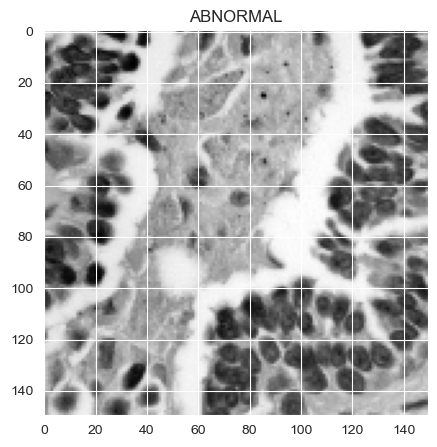

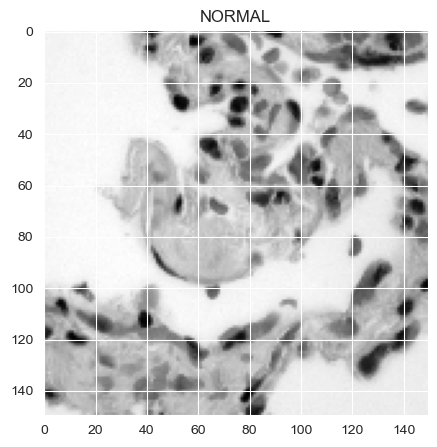

In [10]:
labels = ['ABNORMAL', 'NORMAL']

plt.figure(figsize = (5,5))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[1][0]])

plt.figure(figsize = (5,5))
plt.imshow(train[0][-1], cmap='gray')
plt.title(labels[train[1][-1]])

'''
plt.figure(figsize = (5,5))
plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize = (5,5))
plt.imshow(train[-1][0], cmap='gray')
plt.title(labels[train[-1][1]])
'''

**Next, we perform some Data Preprocessing and Data Augmentation before we can proceed with building the model.**

In [11]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

train_feature = train[0]
train_label = train[1]

test_feature = test[0]
test_label = test[1]

val_feature = val[0]
val_label = val[1]

for feature in train_feature:
    x_train.append(feature)

for label in train_label:
    y_train.append(label)

for feature in test_feature:
    x_test.append(feature)

for label in test_label:
    y_test.append(label)
    
for feature in val_feature:
    x_val.append(feature)

for label in val_label:
    y_val.append(label)

'''
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)
    
for feature, label in val:
    x_val.append(feature)
    y_val.append(label)
'''

'\nx_train = []\ny_train = []\n\nx_val = []\ny_val = []\n\nx_test = []\ny_test = []\n\nfor feature, label in train:\n    x_train.append(feature)\n    y_train.append(label)\n\nfor feature, label in test:\n    x_test.append(feature)\n    y_test.append(label)\n    \nfor feature, label in val:\n    x_val.append(feature)\n    y_val.append(label)\n'

**We perform a grayscale normalization to reduce the effect of illumination's differences.Moreover the CNN converges faster on [0..1] data than on [0..255].**

### **Normalizing the data**

In [12]:
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

# resize data for deep learning 
x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

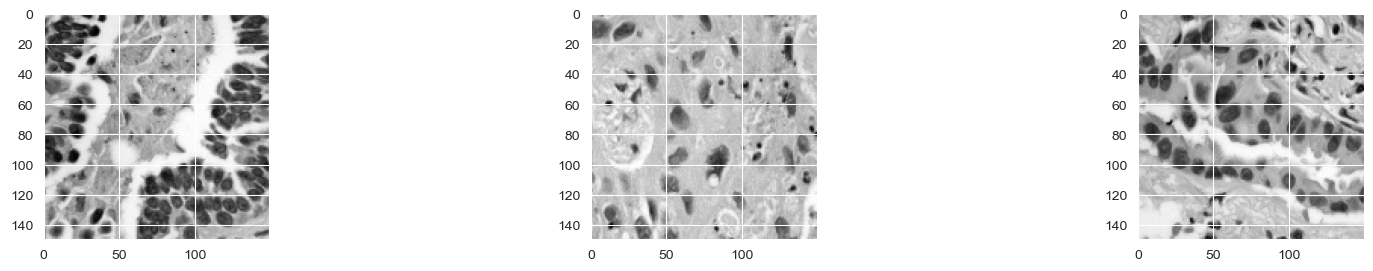

In [13]:
plt.figure(figsize=(20, 10))
plt.subplot(3, 3, 1)
plt.imshow(x_train[0], cmap='gray')
plt.subplot(3, 3, 2)
plt.imshow(x_test[0], cmap='gray')
plt.subplot(3, 3, 3)
plt.imshow(x_val[0], cmap='gray')
plt.show() 

# Data Augmentation
**In order to avoid overfitting problem, we need to expand artificially our dataset. We can make your existing dataset even larger. The idea is to alter the training data with small transformations to reproduce the variations.
Approaches that alter the training data in ways that change the array representation while keeping the label the same are known as data augmentation techniques. Some popular augmentations people use are grayscales, horizontal flips, vertical flips, random crops, color jitters, translations, rotations, and much more.
By applying just a couple of these transformations to our training data, we can easily double or triple the number of training examples and create a very robust model.**

For the data augmentation, i choosed to :
1. Randomly rotate some training images by 30 degrees 
2. Randomly Zoom by 20% some training images
3. Randomly shift images horizontally by 10% of the width 
4. Randomly shift images vertically by 10% of the height 
5. Randomly flip images horizontally.
Once our model is ready, we fit the training dataset.

In [14]:
# With data augmentation to prevent overfitting and handling the imbalance in dataset

datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        rotation_range = 30,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.2, # Randomly zoom image 
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=False)  # randomly flip images


datagen.fit(x_train)

# Training the Model

**Basic Structure of CNN**

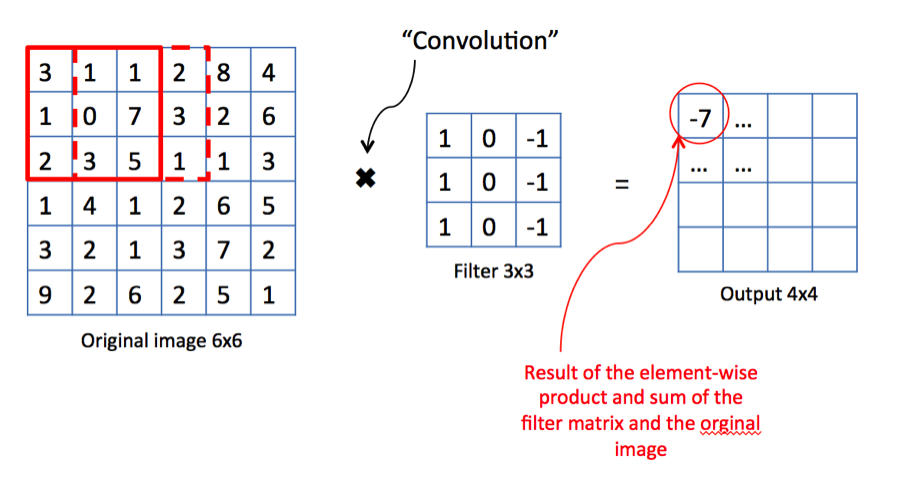

**SAME Padding: it applies padding to the input image so that the input image gets fully covered by the filter and specified stride.It is called SAME because, for stride 1 , the output will be the same as the input.**

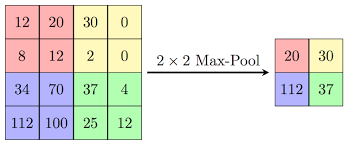


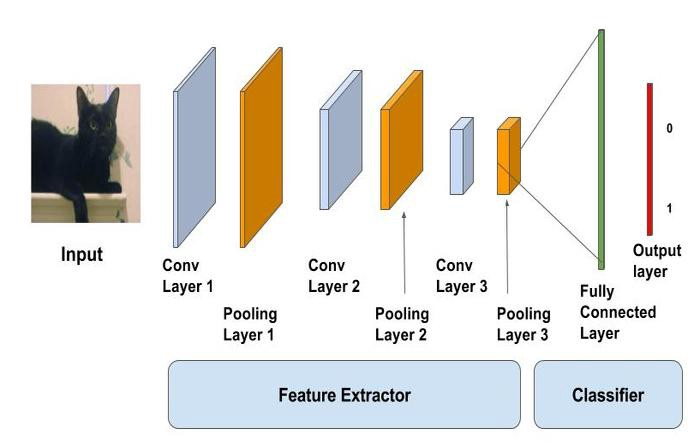
<img src="Assests/download1.png" width="700">


In [15]:
model = Sequential()
model.add(Conv2D(32 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu' , input_shape = (150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(64 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(128 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Conv2D(256 , (3,3) , strides = 1 , padding = 'same' , activation = 'relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2) , strides = 2 , padding = 'same'))
model.add(Flatten())
model.add(Dense(units = 128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(units = 1 , activation = 'sigmoid'))
model.compile(optimizer = "rmsprop" , loss = 'binary_crossentropy' , metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (Batch  (None, 150, 150, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 dropout (Dropout)           (None, 75, 75, 64)        0         
                                                                 
 batch_normalization_1 (Bat  (None, 75, 75, 64)        2

In [16]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [17]:
history = model.fit(datagen.flow(x_train,y_train, batch_size = 32) ,epochs = 12 , validation_data = datagen.flow(x_val, y_val) ,callbacks = [learning_rate_reduction])

Epoch 1/12
94/94 [==============================] - 40s 415ms/step - loss: 0.8035 - accuracy: 0.8613 - val_loss: 10.7167 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 2/12
94/94 [==============================] - 38s 405ms/step - loss: 0.2475 - accuracy: 0.9163 - val_loss: 10.0436 - val_accuracy: 0.6667 - lr: 0.0010
Epoch 3/12
94/94 [==============================] - 38s 410ms/step - loss: 0.1779 - accuracy: 0.9357 - val_loss: 1.0570 - val_accuracy: 0.7102 - lr: 0.0010
Epoch 4/12
94/94 [==============================] - 38s 405ms/step - loss: 0.1673 - accuracy: 0.9500 - val_loss: 2.6178 - val_accuracy: 0.5143 - lr: 0.0010
Epoch 5/12
94/94 [==============================] - ETA: 0s - loss: 0.1288 - accuracy: 0.9583
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
94/94 [==============================] - 38s 408ms/step - loss: 0.1288 - accuracy: 0.9583 - val_loss: 4.4254 - val_accuracy: 0.4987 - lr: 0.0010
Epoch 6/12
94/94 [==============================] - 41s 432

In [18]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

188/188 [==============================] - 13s 68ms/step - loss: 1.3476 - accuracy: 0.8260
Loss of the model is -  1.347630500793457
188/188 [==============================] - 13s 70ms/step - loss: 1.3476 - accuracy: 0.8260
Accuracy of the model is -  82.59999752044678 %


In [19]:
print(x_test.shape)
print(y_test.shape)


(6000, 150, 150, 1)
(6000,)


# Analysis after Model Training

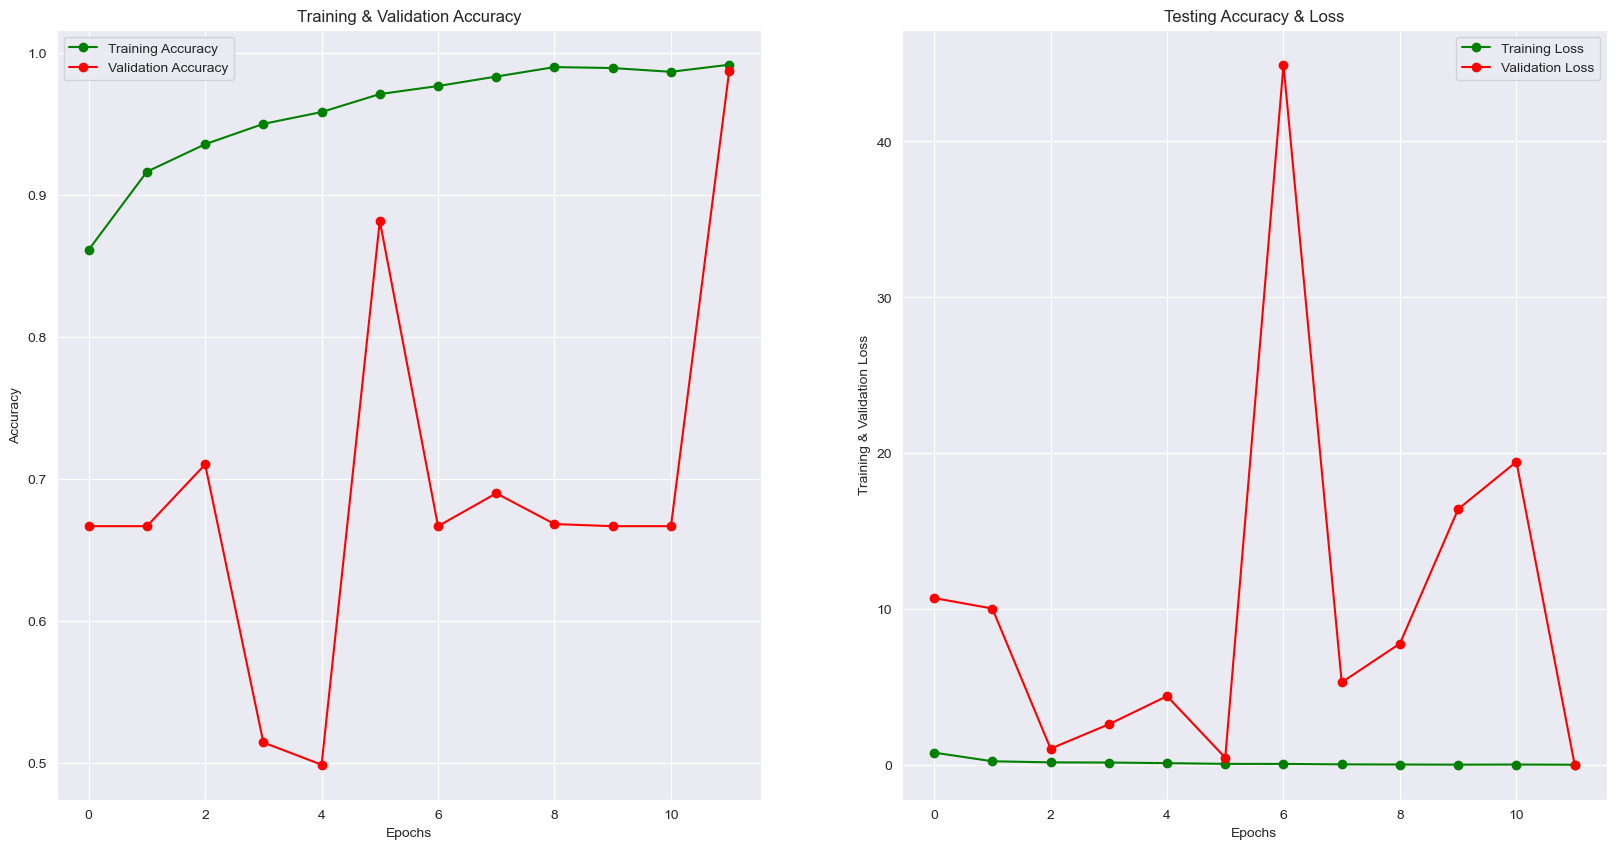

In [20]:
epochs = [i for i in range(12)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
fig.set_size_inches(20,10)

ax[0].plot(epochs , train_acc , 'go-' , label = 'Training Accuracy')
ax[0].plot(epochs , val_acc , 'ro-' , label = 'Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

ax[1].plot(epochs , train_loss , 'g-o' , label = 'Training Loss')
ax[1].plot(epochs , val_loss , 'r-o' , label = 'Validation Loss')
ax[1].set_title('Testing Accuracy & Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Training & Validation Loss")
plt.show()

# Predictions

In [21]:
predictions = model.predict(x_test)
predictions = predictions.reshape(1,-1)[0]
predictions[:15]


188/188 [==============================] - 13s 69ms/step


array([0.0000000e+00, 0.0000000e+00, 2.8410832e-23, 0.0000000e+00,
       4.9013957e-29, 1.5324771e-08, 0.0000000e+00, 0.0000000e+00,
       2.1747106e-26, 9.7864665e-33, 1.2200424e-25, 7.2449776e-30,
       9.7228188e-14, 7.2594301e-27, 0.0000000e+00], dtype=float32)

In [22]:
def binary_convert(x, threshold=0.5):
    return np.where(x > threshold, 1, 0)

In [23]:
predictions = binary_convert(predictions)

In [24]:
print(classification_report(y_test, predictions, target_names = ['Abnormal (Class 0)','Normal (Class 1)']))

                    precision    recall  f1-score   support

Abnormal (Class 0)       0.79      1.00      0.88      4000
  Normal (Class 1)       1.00      0.48      0.65      2000

          accuracy                           0.83      6000
         macro avg       0.90      0.74      0.77      6000
      weighted avg       0.86      0.83      0.81      6000



In [25]:
mcc = matthews_corrcoef(y_test, predictions)
print("Matthews Correlation Coefficient (MCC):", mcc)

Matthews Correlation Coefficient (MCC): 0.6154826244700949


In [26]:
cm = confusion_matrix(y_test,predictions)
cm

array([[3999,    1],
       [1043,  957]])

In [27]:
cm = pd.DataFrame(cm , index = ['0','1'] , columns = ['0','1'])

<Axes: >

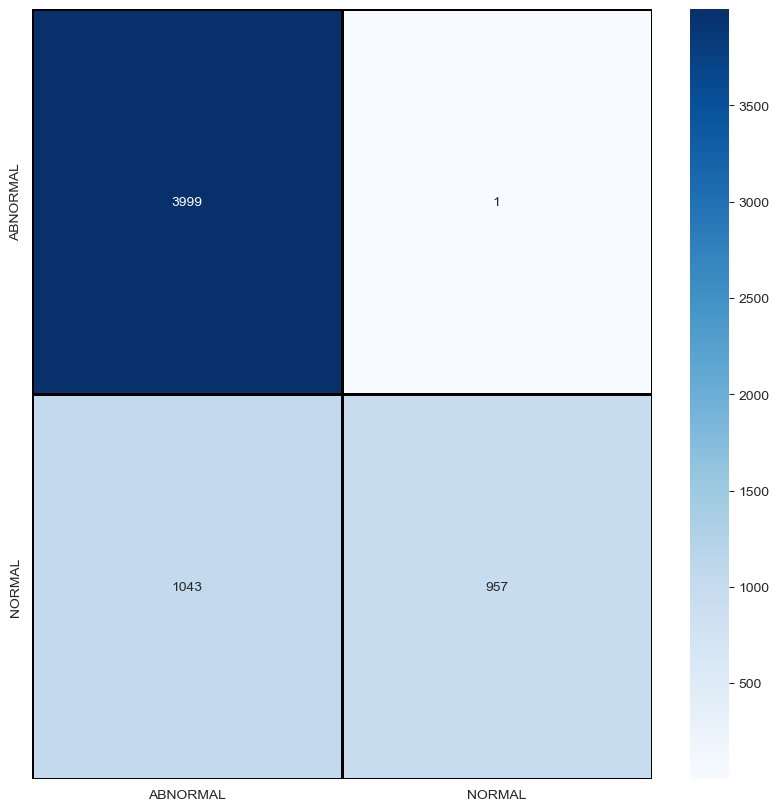

In [28]:
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='',xticklabels = labels,yticklabels = labels)

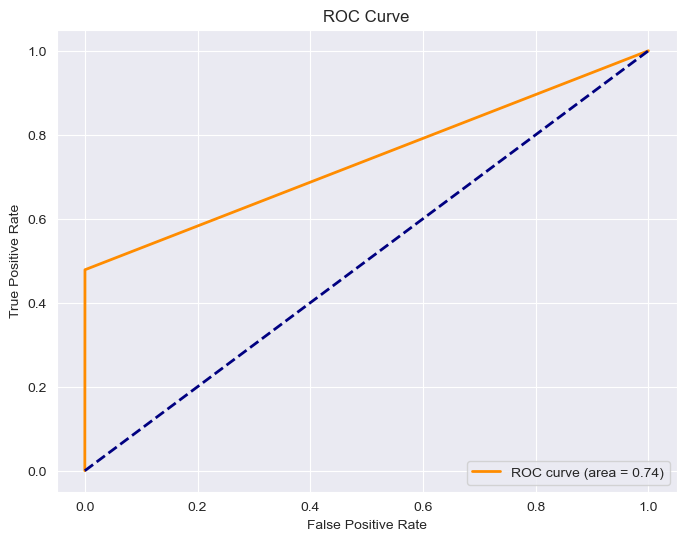

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

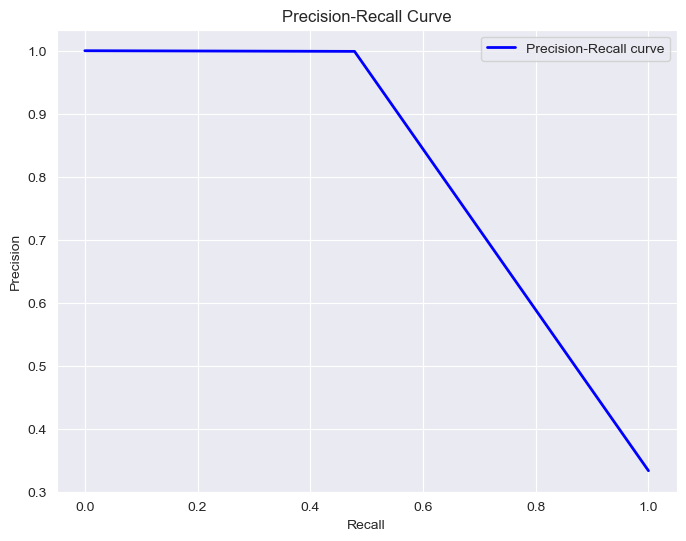

In [30]:
precision, recall, thresholds = precision_recall_curve(y_test, predictions)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.show()

In [31]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

**Some of the Correctly Predicted Classes**

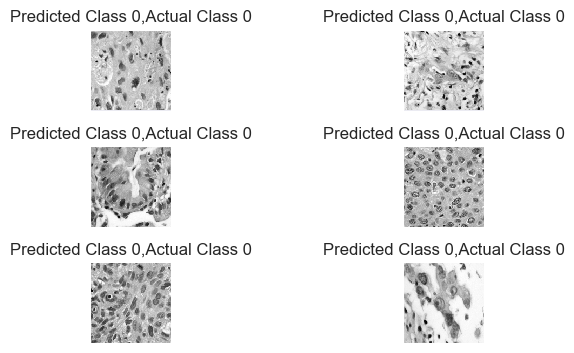

In [32]:
i = 0
for c in correct[:6]:
    plt.subplot(4,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

**Some of the Incorrectly Predicted Classes**

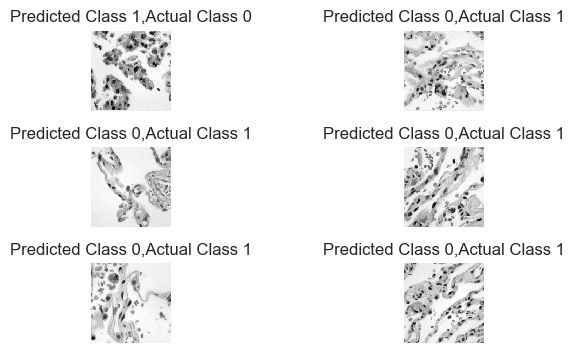

In [33]:
i = 0
for c in incorrect[:6]:
    plt.subplot(4,2,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_test[c].reshape(150,150), cmap="gray", interpolation='none')
    plt.title("Predicted Class {},Actual Class {}".format(predictions[c], y_test[c]))
    plt.tight_layout()
    i += 1

In [34]:
img_size = 150
def manual_prediction(image_path):
    img_test = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_test = cv2.resize(img_test, (img_size, img_size))
    img_test = np.expand_dims(img_test, axis=0)
    img_test = np.expand_dims(img_test, axis=-1)

    img_test = np.array(img_test) / 255

    #print("Input shape:", img_test.shape)
    #print("Input:", img_test[:5][0])
    
    manual_predictions = model.predict(img_test)
    manual_predicted_class = binary_convert(manual_predictions)

    print("Raw predictions:", manual_predictions)
    print("Predicted class:", manual_predicted_class)

    #img_test = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    #plt.imshow(img_test, cmap='gray')
    #plt.show()  


In [35]:
manual_prediction("data/random_predictions/0-1445.jpeg")
manual_prediction("data/random_predictions/0-1453.jpeg")
manual_prediction("data/random_predictions/0-1454.jpeg")
manual_prediction("data/random_predictions/0-1473.jpeg")
manual_prediction("data/random_predictions/0-1483.jpeg")
manual_prediction("data/random_predictions/0-1488.jpeg")

1/1 [==============================] - 0s 20ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]
1/1 [==============================] - 0s 18ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]
1/1 [==============================] - 0s 18ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]
1/1 [==============================] - 0s 15ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]
1/1 [==============================] - 0s 16ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]
1/1 [==============================] - 0s 15ms/step
Raw predictions: [[0.]]
Predicted class: [[0]]


In [36]:
manual_prediction("data/random_predictions/1-4621.jpeg")
manual_prediction("data/random_predictions/1-4623.jpeg")
manual_prediction("data/random_predictions/1-4627.jpeg")
manual_prediction("data/random_predictions/1-4634.jpeg")
manual_prediction("data/random_predictions/1-4641.jpeg")
manual_prediction("data/random_predictions/1-4669.jpeg")


1/1 [==============================] - 0s 19ms/step
Raw predictions: [[0.6964781]]
Predicted class: [[1]]
1/1 [==============================] - 0s 16ms/step
Raw predictions: [[0.02277685]]
Predicted class: [[0]]
1/1 [==============================] - 0s 15ms/step
Raw predictions: [[0.09153344]]
Predicted class: [[0]]
1/1 [==============================] - 0s 15ms/step
Raw predictions: [[0.00236449]]
Predicted class: [[0]]
1/1 [==============================] - 0s 16ms/step
Raw predictions: [[0.10736479]]
Predicted class: [[0]]
1/1 [==============================] - 0s 14ms/step
Raw predictions: [[1.3574952e-05]]
Predicted class: [[0]]


In [37]:
#model.save("models/lung_model_20%train_02_07_24.h5")

/Users/Kyle/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
